<a href="https://colab.research.google.com/github/tanmaysaxena18/GFG-21-days-Deep-Learning-Projects/blob/main/Analyzing_Historical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:57: SyntaxWarning: invalid escape sequence '\$'
<>:81: SyntaxWarning: invalid escape sequence '\$'
<>:57: SyntaxWarning: invalid escape sequence '\$'
<>:81: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-438222045.py:57: SyntaxWarning: invalid escape sequence '\$'
  tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"", regex=True)
/tmp/ipython-input-438222045.py:81: SyntaxWarning: invalid escape sequence '\$'
  gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(',|\$',"", regex=True)


--- Extracting Tesla Stock Data ---
                       Date      Open      High       Low     Close  \
0 2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667   
1 2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667   
2 2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000   
3 2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   
4 2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000   

      Volume  Dividends  Stock Splits  
0  281494500        0.0           0.0  
1  257806500        0.0           0.0  
2  123282000        0.0           0.0  
3   77097000        0.0           0.0  
4  103003500        0.0           0.0  

--- Extracting Tesla Revenue Data ---
          Date Revenue
48  2010-09-30      31
49  2010-06-30      28
50  2010-03-31      21
52  2009-09-30      46
53  2009-06-30      27

--- Extracting GameStop Stock Data ---
                       Date      Open      High       Low     Close    Volume  \

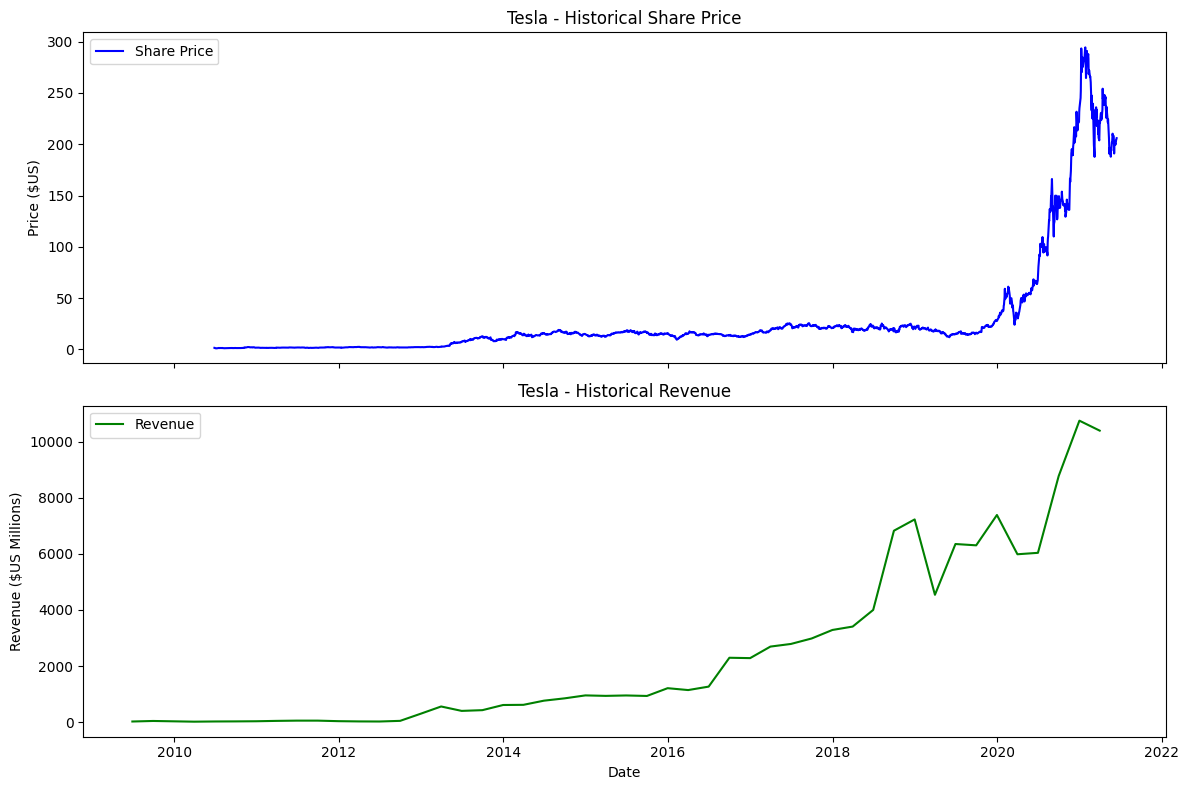


--- Generating GameStop Dashboard ---


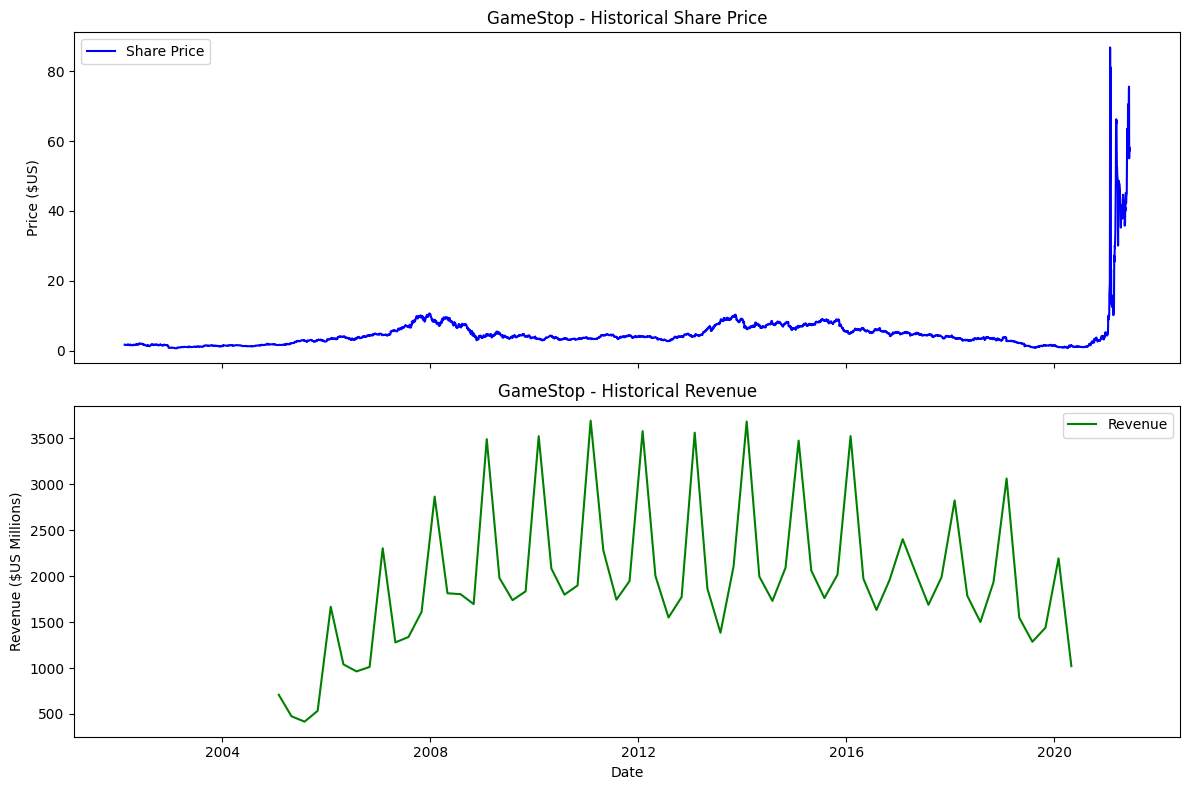

In [ ]:

!pip install yfinance bs4 nbformat matplotlib pandas requests

#IMPORT
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings("ignore", category=FutureWarning)

#DEFINING GRAPH FUNCTION
def make_graph(stock_data, revenue_data, stock):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    #Filter data (as per assignment requirements)
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    #Plot Stock Price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")
    axes[0].legend()

    #Plot Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

#Q1 EXTRACT TESLA STOCK DATA
print("--- Extracting Tesla Stock Data ---")
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)
print(tesla_data.head())

#Q2: EXTRACT TESLA REVENUE DATA
print("\n--- Extracting Tesla Revenue Data ---")
url_tsla = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data = requests.get(url_tsla).text
soup = BeautifulSoup(html_data, 'html.parser')

#Extract table (usually index 1 is the quarterly revenue)
tables = pd.read_html(str(soup))
tesla_revenue = tables[1]
tesla_revenue.columns = ["Date", "Revenue"]

#Clean the data
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"", regex=True)
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]
print(tesla_revenue.tail())

#Q3 EXTRACT GAMESTOP STOCK DATA
print("\n--- Extracting GameStop Stock Data ---")
gme = yf.Ticker("GME")
gme_data = gme.history(period="max")
gme_data.reset_index(inplace=True)
print(gme_data.head())

#Q4: EXTRACT GAMESTOP REVENUE DATA
print("\n--- Extracting GameStop Revenue Data ---")
url_gme = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_2 = requests.get(url_gme).text
soup_2 = BeautifulSoup(html_data_2, 'html.parser')

#Extract table
tables_gme = pd.read_html(str(soup_2))
gme_revenue = tables_gme[1]
gme_revenue.columns = ["Date", "Revenue"]

#Clean the data
gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(',|\$',"", regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]
print(gme_revenue.tail())

#Q5 PLOT TESLA GRAPH
print("\n--- Generating Tesla Dashboard ---")
make_graph(tesla_data, tesla_revenue, 'Tesla')

#Q6: PLOT GAMESTOP GRAPH
print("\n--- Generating GameStop Dashboard ---")
make_graph(gme_data, gme_revenue, 'GameStop')